# Testing Functions

In [1]:
import sys
sys.path.append(r'..\src\eegfmri_denoising')
import mne
from simulation import SphereModel, PulseSequence, GradientArtefact

In [6]:
#montage = mne.channels.make_standard_montage("standard_1020")
montage = mne.channels.make_standard_montage("biosemi32")

info = mne.create_info(ch_names=montage.ch_names, sfreq=5000.0, ch_types="eeg")
info.set_montage(montage)

<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, AF3, F7, F3, FC1, FC5, T7, C3, CP1, CP5, P7, P3, Pz, PO3, ...
 chs: 32 EEG
 custom_ref_applied: False
 dig: 35 items (3 Cardinal, 32 EEG)
 highpass: 0.0 Hz
 lowpass: 2500.0 Hz
 meas_date: unspecified
 nchan: 32
 projs: []
 sfreq: 5000.0 Hz
>

Creating sphere model...
Fitted sphere radius:         95.0 mm
Origin head coordinates:      0.0 -0.0 40.1 mm
Origin device coordinates:    0.0 -0.0 40.1 mm

Equiv. model fitting -> RV = 0.00348862 %%
mu1 = 0.944723    lambda1 = 0.137154
mu2 = 0.66746    lambda2 = 0.683797
mu3 = -0.267046    lambda3 = -0.0105814
Set up EEG sphere model with scalp radius    95.0 mm

Storing electrode positions...


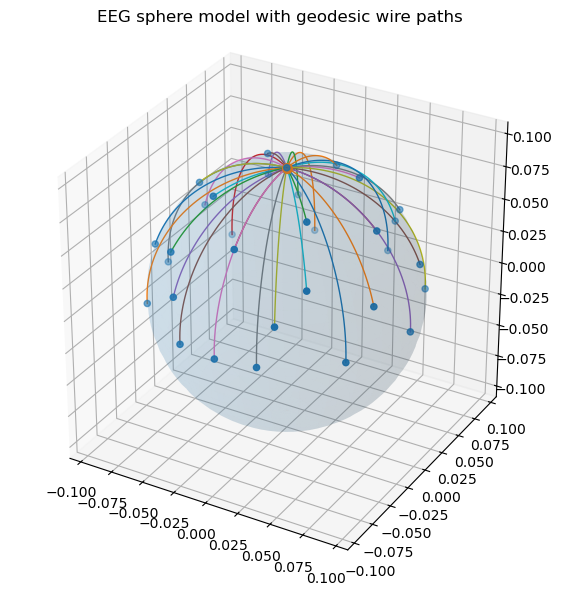

In [7]:
# basic
sphere = SphereModel(info , bore_offset=0)

# plot
sphere.plot()

In [8]:
sequence = PulseSequence()

In [9]:
sequence.load_standard_epi()

Assigning standard EPI sequence...


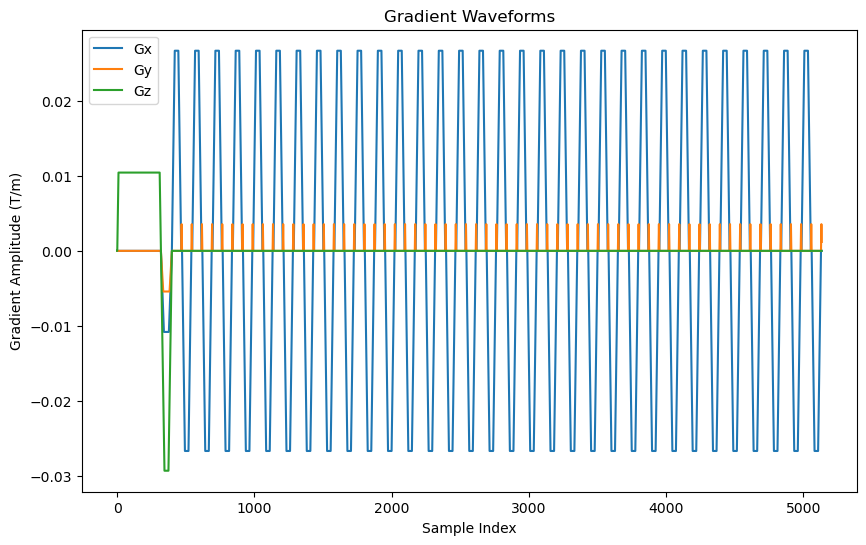

In [10]:
sequence.plot()

In [11]:
artifact = GradientArtefact(sphere, sequence, n_slices=10, n_volumes=10)

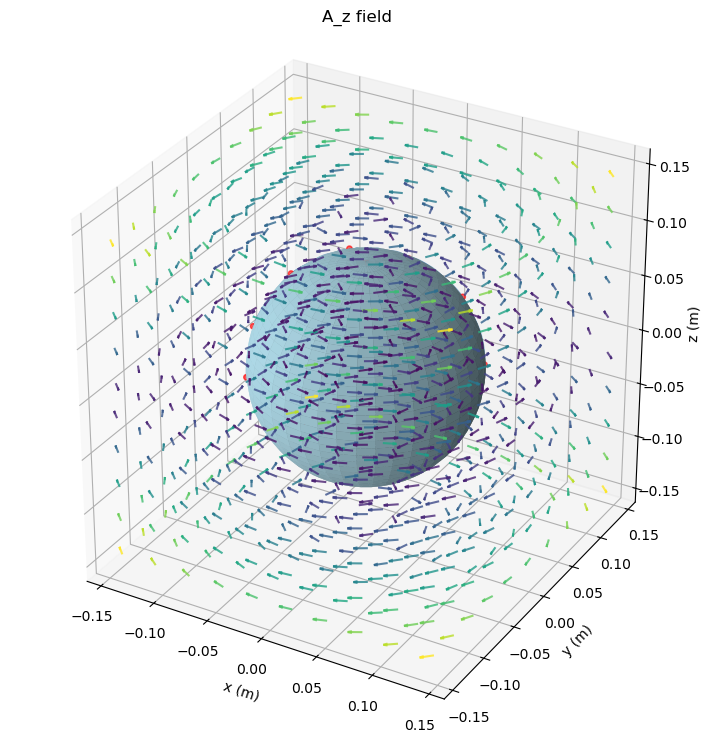

In [12]:
artifact.plot_field(axis = 'z', n_grid = 10)

In [13]:
import numpy as np
artifact.simulate()
print(artifact.V_t.shape)
print(f"Max artefact: {np.max(np.abs(artifact.V_t)):.2f} µV")

(32, 25675)
Max artefact: 31707.39 µV


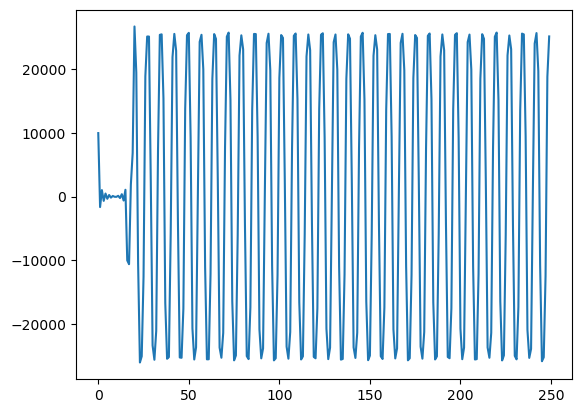

In [14]:
import matplotlib.pyplot as plt
plt.plot(artifact.V_t[1, 0:250])
plt.show()

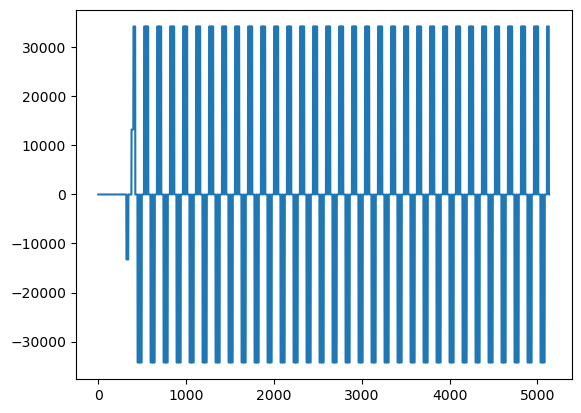

In [15]:
import matplotlib.pyplot as plt
plt.plot(artifact.Vx_all[0, :])
plt.show()

In [16]:
import mne
import numpy as np

# pick 10 channels
n_ch = 70
ch_idx = np.linspace(0, artifact.V_t.shape[0]-1, n_ch, dtype=int)
data = artifact.V_t[ch_idx, :]   # (10, n_samples) — already in µV

# convert to Volts for MNE
data_v = data * 1e-6

# create MNE info
ch_names = [artifact.sphere.ch_names[i] for i in ch_idx]
info = mne.create_info(ch_names=ch_names, sfreq=artifact.eeg_sfreq, ch_types='eeg')

# create Raw object
raw = mne.io.RawArray(data_v, info)

# plot PSD
raw.set_montage(montage)
raw.compute_psd(fmax = 126, n_fft = 10000).plot(dB=False)
plt.show()

Creating RawArray with float64 data, n_channels=70, n_times=25675
    Range : 0 ... 25674 =      0.000 ...     5.135 secs
Ready.


C:\Users\brand\AppData\Local\Temp\ipykernel_46800\309445815.py:14: RuntimeWarning: Channel names are not unique, found duplicates for: {'F4', 'C4', 'Fz', 'O2', 'CP1', 'F8', 'Pz', 'CP5', 'CP6', 'T7', 'FC1', 'Oz', 'P7', 'P8', 'P3', 'AF4', 'AF3', 'F7', 'PO4', 'Fp2', 'P4', 'O1', 'CP2', 'FC2', 'FC6', 'PO3', 'C3', 'Fp1', 'T8', 'F3', 'FC5'}. Applying running numbers for duplicates.
  info = mne.create_info(ch_names=ch_names, sfreq=artifact.eeg_sfreq, ch_types='eeg')


ValueError: DigMontage is only a subset of info. There are 69 channel positions not present in the DigMontage. The channels missing from the montage are:

['Fp1-0', 'Fp1-1', 'Fp1-2', 'AF3-0', 'AF3-1', 'F7-0', 'F7-1', 'F3-0', 'F3-1', 'FC1-0', 'FC1-1', 'FC1-2', 'FC5-0', 'FC5-1', 'T7-0', 'T7-1', 'C3-0', 'C3-1', 'CP1-0', 'CP1-1', 'CP1-2', 'CP5-0', 'CP5-1', 'P7-0', 'P7-1', 'P3-0', 'P3-1', 'Pz-0', 'Pz-1', 'PO3-0', 'PO3-1', 'PO3-2', 'O1-0', 'O1-1', 'Oz-0', 'Oz-1', 'O2-0', 'O2-1', 'PO4-0', 'PO4-1', 'PO4-2', 'P4-0', 'P4-1', 'P8-0', 'P8-1', 'CP6-0', 'CP6-1', 'CP2-0', 'CP2-1', 'C4-0', 'C4-1', 'C4-2', 'T8-0', 'T8-1', 'FC6-0', 'FC6-1', 'FC2-0', 'FC2-1', 'F4-0', 'F4-1', 'F4-2', 'F8-0', 'F8-1', 'AF4-0', 'AF4-1', 'Fp2-0', 'Fp2-1', 'Fz-0', 'Fz-1'].

Consider using inst.rename_channels to match the montage nomenclature, or inst.set_channel_types if these are not EEG channels, or use the on_missing parameter if the channel positions are allowed to be unknown in your analyses.

In [17]:
raw.plot()

Using qt as 2D backend.


<mne_qt_browser._pg_figure.MNEQtBrowser(0x17486ac1e70) at 0x0000017471591600>

Channels marked as bad:
none


In [19]:
slice_duration = len(artifact.Gz) / artifact.sfreq
f_GA = 1 / slice_duration

print(f"slice duration: {slice_duration*1000:.2f} ms")
print(f"fundamental GA frequency: {f_GA:.2f} Hz")

slice duration: 51.35 ms
fundamental GA frequency: 19.47 Hz


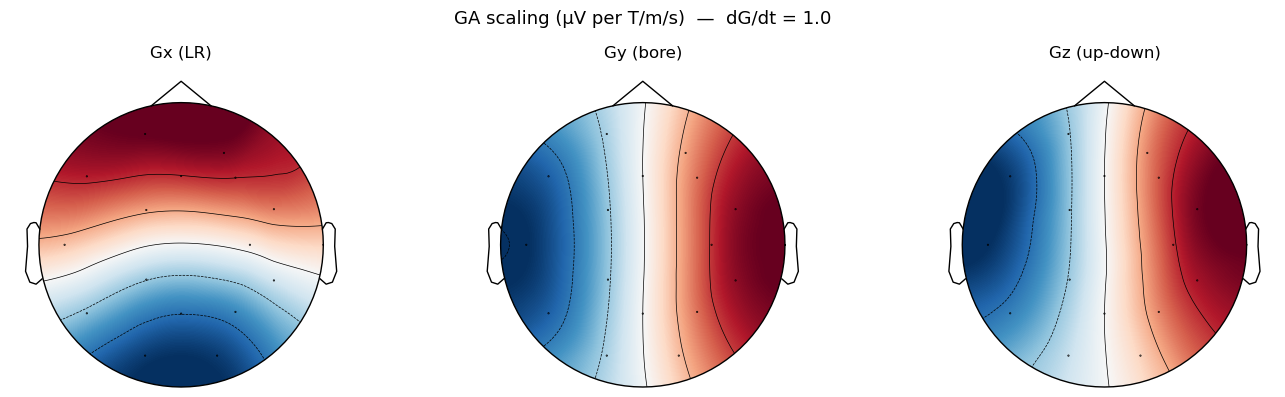

In [23]:
import matplotlib.pyplot as plt

r      = artifact.sphere.radius
center = artifact.sphere.center
x0, y0, z0 = center

ref_idx   = artifact.sphere.ch_names.index('Cz')
ref_ep    = artifact.sphere.eeg_coords_proj[ref_idx] - center
ref_phi   = np.arctan2(ref_ep[1], ref_ep[0])
ref_theta = np.arccos(np.clip(ref_ep[2] / r, -1, 1))

n_ch = len(artifact.sphere.ch_names)
sx, sy, sz = np.zeros(n_ch), np.zeros(n_ch), np.zeros(n_ch)

for i, ep in enumerate(artifact.sphere.eeg_coords_proj):
        ep_rel = ep - center
        phi    = np.arctan2(ep_rel[1], ep_rel[0]) 
        theta  = np.arccos(np.clip(ep_rel[2] / r, -1, 1))
        sx[i] = (artifact.get_Vx(r, theta, phi, 2.0, x0, y0, z0) -
                artifact.get_Vx(r, ref_theta, ref_phi, 2.0, x0, y0, z0)) * 1e6
        sy[i] = (artifact.get_Vy(r, theta, phi, 2.0, x0, y0, z0, alpha=0) -
                artifact.get_Vy(r, ref_theta, ref_phi, 2.0, x0, y0, z0, alpha = 0)) * 1e6
        sz[i] = (artifact.get_Vz(r, theta, phi, 2.0, x0, y0, z0,alpha = np.radians(-15)) -
                artifact.get_Vz(r, ref_theta, ref_phi, 2.0, x0, y0, z0, alpha = np.radians(-15))) * 1e6

idx = np.arange(0, n_ch, 2)
ch_names_sub = [artifact.sphere.ch_names[i] for i in idx]
info_sub = mne.pick_info(artifact.sphere.info,
    mne.pick_channels(artifact.sphere.info['ch_names'], ch_names_sub))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, s, title in zip(axes,
                         [sx[idx], sy[idx], sz[idx]],
                         ['Gx (LR)', 'Gy (bore)', 'Gz (up-down)']):
    mne.viz.plot_topomap(s, info_sub, axes=ax, show=False,
                         cmap='RdBu_r',
                         vlim=(-np.max(np.abs(s)), np.max(np.abs(s))))
    ax.set_title(title)

plt.suptitle('GA scaling (µV per T/m/s)  —  dG/dt = 1.0', fontsize=13)
plt.tight_layout()
plt.show()

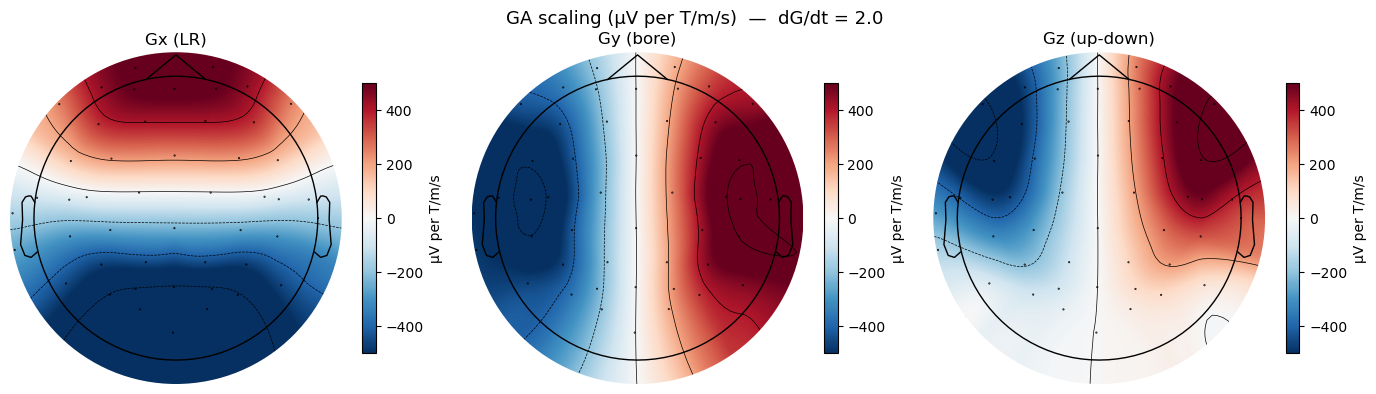

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, s, title in zip(axes,
                         [sx[idx], sy[idx], sz[idx]],
                         ['Gx (LR)', 'Gy (bore)', 'Gz (up-down)']):
    im, _ = mne.viz.plot_topomap(s, info_sub, axes=ax, show=False,
                                  cmap='RdBu_r',
                                  vlim=(-500, 500))
    plt.colorbar(im, ax=ax, label='µV per T/m/s', shrink=0.8)
    ax.set_title(title)

plt.suptitle('GA scaling (µV per T/m/s)  —  dG/dt = 2.0', fontsize=13)
plt.tight_layout()
plt.show()

In [28]:
# are these the same?
print("sx subset channels:", [artifact.sphere.ch_names[i] for i in idx[:5]])
print("info_sub channels:", info_sub['ch_names'][:5])

sx subset channels: ['Fp1', 'Fp2', 'AF7', 'AF3', 'AFz']
info_sub channels: ['Fp1', 'Fp2', 'AF7', 'AF3', 'AFz']


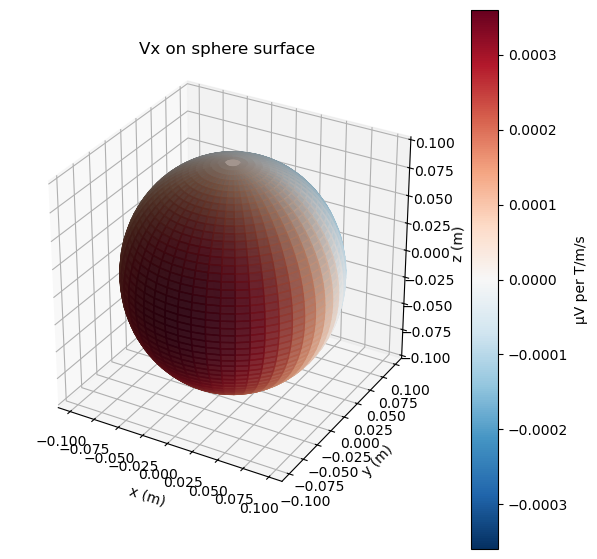

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

r      = artifact.sphere.radius
center = artifact.sphere.center
x0, y0, z0 = center

# create sphere surface points
n = 50
u = np.linspace(0, 2*np.pi, n)
v = np.linspace(0, np.pi, n)
U, V = np.meshgrid(u, v)

# cartesian coordinates on sphere surface
X = r * np.sin(V) * np.cos(U)
Y = r * np.sin(V) * np.sin(U)
Z = r * np.cos(V)

# spherical coordinates of each surface point
phi_grid   = np.arctan2(Y, X)
theta_grid = np.arccos(np.clip(Z / r, -1, 1))

# reference (Cz)
ref_idx   = artifact.sphere.ch_names.index('Cz')
ref_ep    = artifact.sphere.eeg_coords_proj[ref_idx] - center
ref_phi   = np.arctan2(ref_ep[1], ref_ep[0])
ref_theta = np.arccos(np.clip(ref_ep[2] / r, -1, 1))

# evaluate Vx at every surface point
Vx_surf = artifact.get_Vx(r, theta_grid, phi_grid, 1.0, x0, y0, z0) - \
          artifact.get_Vx(r, ref_theta, ref_phi, 1.0, x0, y0, z0)

fig = plt.figure(figsize=(7, 7))
ax  = fig.add_subplot(111, projection='3d')

vmax = np.max(np.abs(Vx_surf))
surf = ax.plot_surface(X + center[0], Y + center[1], Z + center[2],
                       facecolors=plt.cm.RdBu_r((Vx_surf + vmax) / (2*vmax)),
                       alpha=0.9)

ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_zlabel('z (m)')
ax.set_title('Vx on sphere surface')
ax.set_box_aspect([1,1,1])

import matplotlib.cm as cm
import matplotlib.colorbar as cbar
mappable = plt.cm.ScalarMappable(cmap='RdBu_r')
mappable.set_array(Vx_surf)
mappable.set_clim(-vmax, vmax)
plt.colorbar(mappable, ax=ax, label='µV per T/m/s')

plt.show()

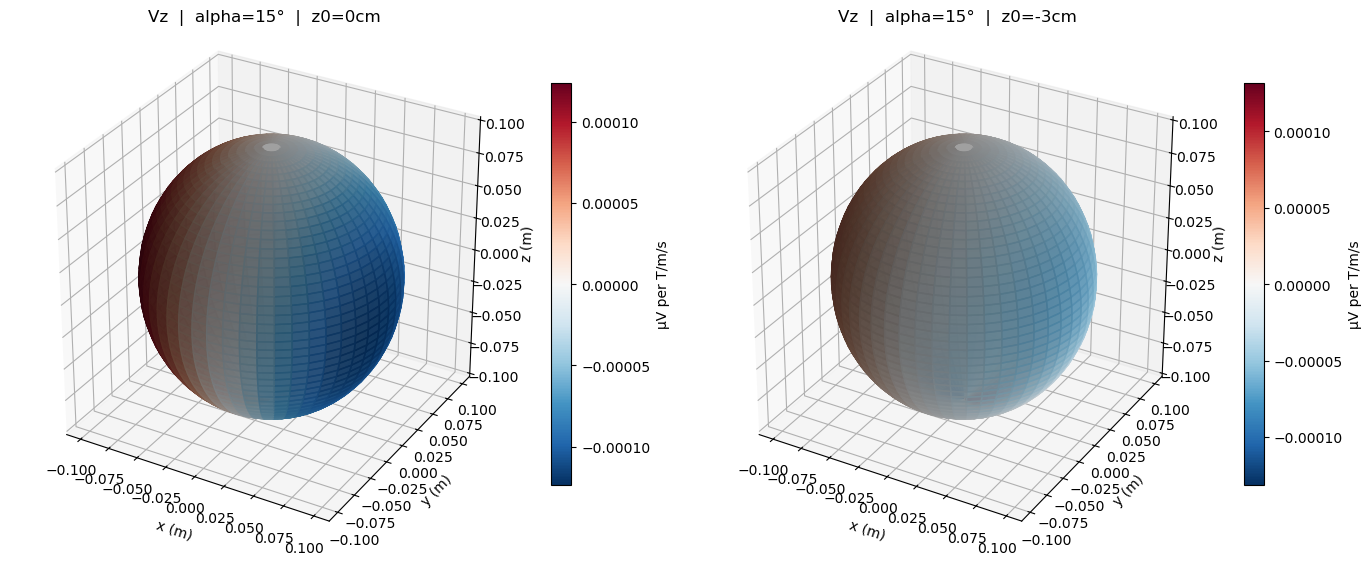

In [51]:
import matplotlib.pyplot as plt
import numpy as np

r      = artifact.sphere.radius
center = artifact.sphere.center

n = 50
u = np.linspace(0, 2*np.pi, n)
v = np.linspace(0, np.pi, n)
U, V = np.meshgrid(u, v)

X = r * np.sin(V) * np.cos(U)
Y = r * np.sin(V) * np.sin(U)
Z = r * np.cos(V)

phi_grid   = np.arctan2(-Y, -X)   # MNE convention
theta_grid = np.arccos(np.clip(Z / r, -1, 1))

ref_idx   = artifact.sphere.ch_names.index('Cz')
ref_ep    = artifact.sphere.eeg_coords_proj[ref_idx] - center
ref_phi   = np.arctan2(-ref_ep[1], -ref_ep[0])
ref_theta = np.arccos(np.clip(ref_ep[2] / r, -1, 1))

alpha = np.radians(15)

fig = plt.figure(figsize=(14, 7))

for col, z0 in enumerate([0.0, -0.03]):
    ax = fig.add_subplot(1, 2, col+1, projection='3d')

    Vz_surf = (artifact.get_Vz(r, theta_grid, phi_grid, 1.0, 0, 0, z0, alpha=alpha) -
               artifact.get_Vz(r, ref_theta, ref_phi, 1.0, 0, 0, z0, alpha=alpha))

    vmax = np.max(np.abs(Vz_surf))
    ax.plot_surface(X + center[0], Y + center[1], Z + center[2],
                    facecolors=plt.cm.RdBu_r((Vz_surf + vmax) / (2*vmax)),
                    alpha=0.9)

    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    ax.set_zlabel('z (m)')
    ax.set_title(f'Vz  |  alpha=15°  |  z0={z0*100:.0f}cm')
    ax.set_box_aspect([1,1,1])

    mappable = plt.cm.ScalarMappable(cmap='RdBu_r')
    mappable.set_array(Vz_surf)
    mappable.set_clim(-vmax, vmax)
    plt.colorbar(mappable, ax=ax, label='µV per T/m/s', shrink=0.6)

plt.tight_layout()
plt.show()

C:\Users\brand\AppData\Local\Temp\ipykernel_43052\2855815293.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


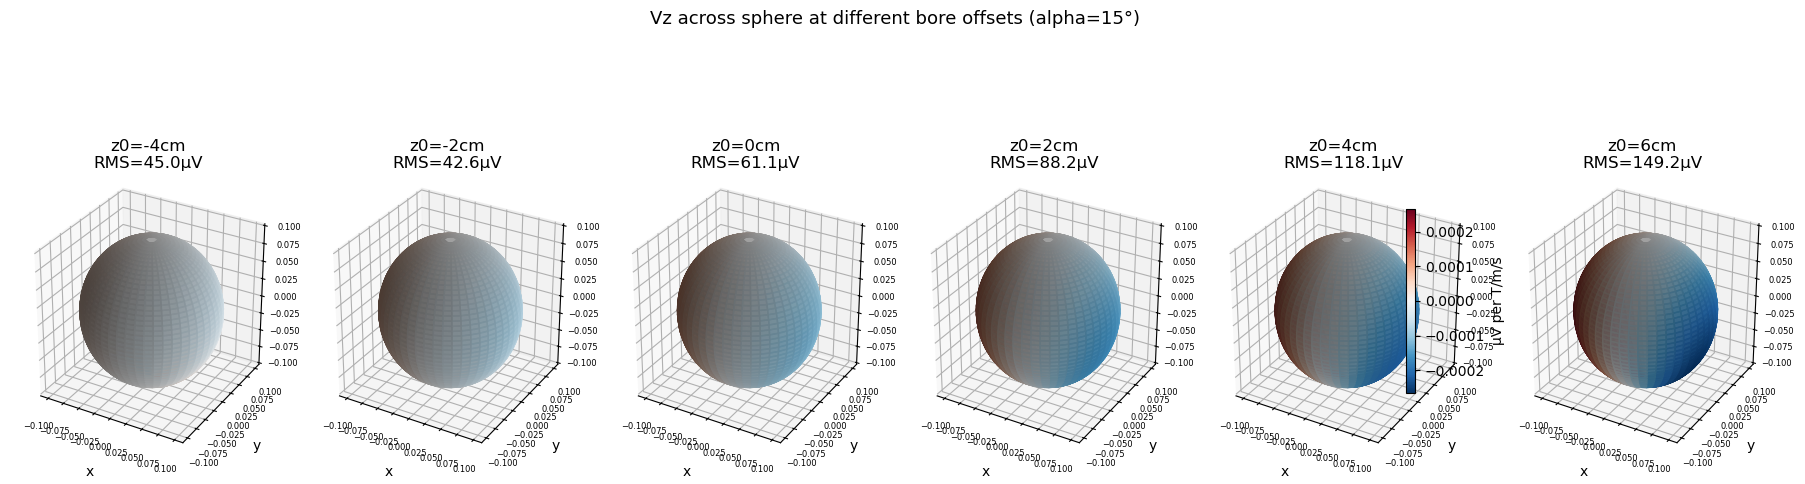

In [54]:
import matplotlib.pyplot as plt
import numpy as np

r      = artifact.sphere.radius
center = artifact.sphere.center
alpha  = np.radians(15)

n = 50
u = np.linspace(0, 2*np.pi, n)
v = np.linspace(0, np.pi, n)
U, V = np.meshgrid(u, v)

X = r * np.sin(V) * np.cos(U)
Y = r * np.sin(V) * np.sin(U)
Z = r * np.cos(V)

phi_grid   = np.arctan2(-Y, -X)
theta_grid = np.arccos(np.clip(Z / r, -1, 1))

ref_idx   = artifact.sphere.ch_names.index('Cz')
ref_ep    = artifact.sphere.eeg_coords_proj[ref_idx] - center
ref_phi   = np.arctan2(-ref_ep[1], -ref_ep[0])
ref_theta = np.arccos(np.clip(ref_ep[2] / r, -1, 1))

z0_values = [-0.04, -0.02, 0.0, 0.02, 0.04, 0.06]

# compute all first to get consistent vmax
all_Vz = []
for z0 in z0_values:
    Vz = (artifact.get_Vz(r, theta_grid, phi_grid, 1.0, 0, 0, z0, alpha=alpha) -
          artifact.get_Vz(r, ref_theta, ref_phi, 1.0, 0, 0, z0, alpha=alpha))
    all_Vz.append(Vz)

vmax = max(np.max(np.abs(V)) for V in all_Vz)

fig = plt.figure(figsize=(18, 6))

for col, (z0, Vz) in enumerate(zip(z0_values, all_Vz)):
    ax = fig.add_subplot(1, len(z0_values), col+1, projection='3d')
    ax.plot_surface(X + center[0], Y + center[1], Z + center[2],
                    facecolors=plt.cm.RdBu_r((Vz + vmax) / (2*vmax)),
                    alpha=0.9)
    ax.set_title(f'z0={z0*100:.0f}cm\nRMS={np.sqrt(np.mean(Vz**2))*1e6:.1f}µV')
    ax.set_box_aspect([1,1,1])
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
    ax.tick_params(labelsize=6)

# shared colorbar
mappable = plt.cm.ScalarMappable(cmap='RdBu_r')
mappable.set_clim(-vmax, vmax)
fig.colorbar(mappable, ax=fig.axes, label='µV per T/m/s', shrink=0.4)

plt.suptitle('Vz across sphere at different bore offsets (alpha=15°)', fontsize=13)
plt.tight_layout()
plt.show()

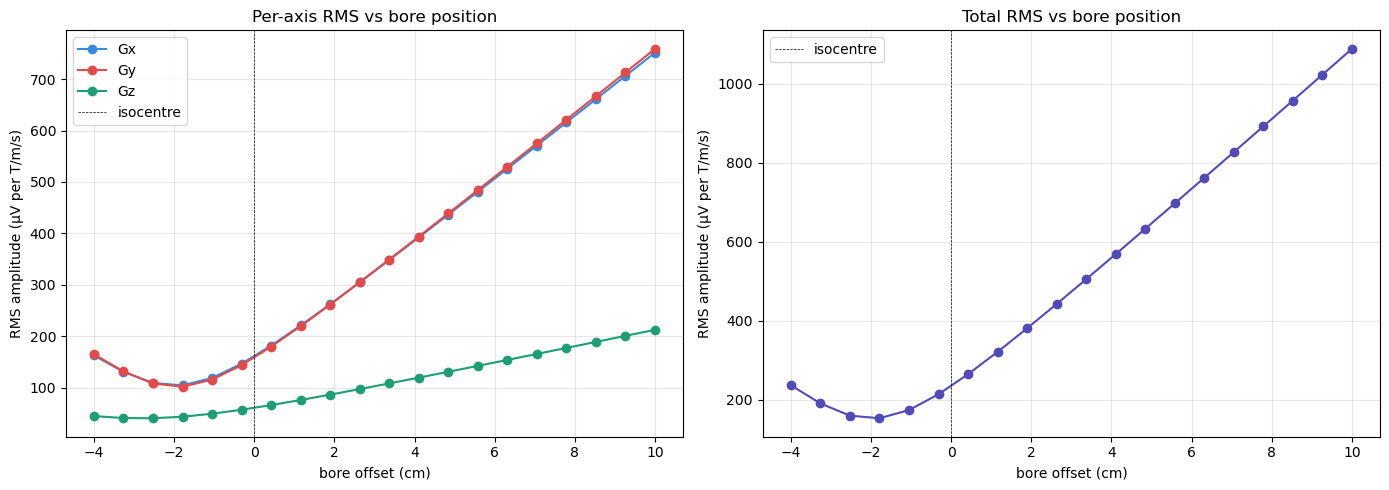

In [55]:
import matplotlib.pyplot as plt
import numpy as np

r      = artifact.sphere.radius
center = artifact.sphere.center
alpha  = np.radians(15)

n = 50
u = np.linspace(0, 2*np.pi, n)
v = np.linspace(0, np.pi, n)
U, V = np.meshgrid(u, v)

X = r * np.sin(V) * np.cos(U)
Y = r * np.sin(V) * np.sin(U)
Z = r * np.cos(V)

phi_grid   = np.arctan2(-Y, -X)
theta_grid = np.arccos(np.clip(Z / r, -1, 1))

ref_idx   = artifact.sphere.ch_names.index('Cz')
ref_ep    = artifact.sphere.eeg_coords_proj[ref_idx] - center
ref_phi   = np.arctan2(-ref_ep[1], -ref_ep[0])
ref_theta = np.arccos(np.clip(ref_ep[2] / r, -1, 1))

bore_offsets = np.linspace(-0.04, 0.10, 20)
rms_x, rms_y, rms_z, rms_total = [], [], [], []

for z0 in bore_offsets:
    Vx = (artifact.get_Vx(r, theta_grid, phi_grid, 1.0, 0, 0, z0) -
          artifact.get_Vx(r, ref_theta, ref_phi, 1.0, 0, 0, z0))
    Vy = (artifact.get_Vy(r, theta_grid, phi_grid, 1.0, 0, 0, z0) -
          artifact.get_Vy(r, ref_theta, ref_phi, 1.0, 0, 0, z0))
    Vz = (artifact.get_Vz(r, theta_grid, phi_grid, 1.0, 0, 0, z0, alpha=alpha) -
          artifact.get_Vz(r, ref_theta, ref_phi, 1.0, 0, 0, z0, alpha=alpha))

    rms_x.append(np.sqrt(np.mean(Vx**2)) * 1e6)
    rms_y.append(np.sqrt(np.mean(Vy**2)) * 1e6)
    rms_z.append(np.sqrt(np.mean(Vz**2)) * 1e6)
    rms_total.append(np.sqrt(np.mean(Vx**2 + Vy**2 + Vz**2)) * 1e6)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(bore_offsets*100, rms_x, 'o-', label='Gx', color='#378ADD')
ax1.plot(bore_offsets*100, rms_y, 'o-', label='Gy', color='#E24B4A')
ax1.plot(bore_offsets*100, rms_z, 'o-', label='Gz', color='#1D9E75')
ax1.axvline(0, color='k', lw=0.5, linestyle='--', label='isocentre')
ax1.set_xlabel('bore offset (cm)')
ax1.set_ylabel('RMS amplitude (µV per T/m/s)')
ax1.set_title('Per-axis RMS vs bore position')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(bore_offsets*100, rms_total, 'o-', color='#534AB7')
ax2.axvline(0, color='k', lw=0.5, linestyle='--', label='isocentre')
ax2.set_xlabel('bore offset (cm)')
ax2.set_ylabel('RMS amplitude (µV per T/m/s)')
ax2.set_title('Total RMS vs bore position')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

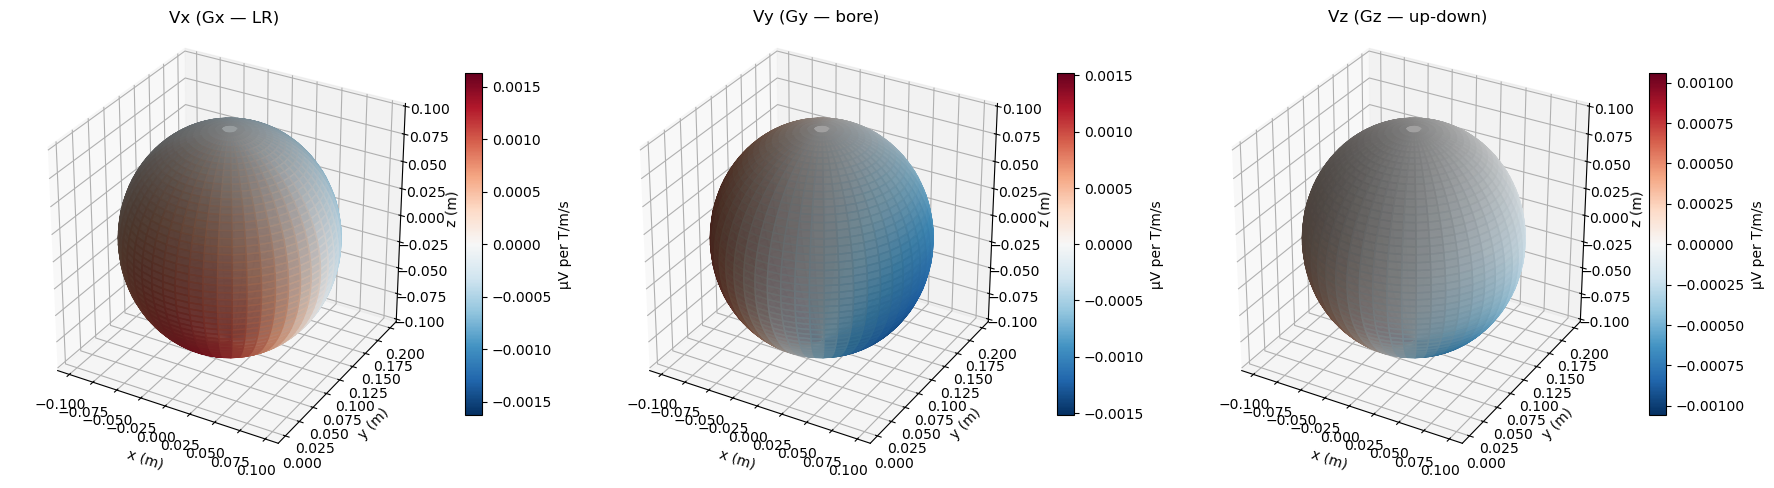

In [50]:
fig = plt.figure(figsize=(18, 6))

funcs = [
    (artifact.get_Vx, 'Vx (Gx — LR)'),
    (artifact.get_Vy, 'Vy (Gy — bore)'),
    (artifact.get_Vz, 'Vz (Gz — up-down)'),
]

for i, (func, title) in enumerate(funcs):
    ax = fig.add_subplot(1, 3, i+1, projection='3d')

    if func == artifact.get_Vz:
        V_surf = func(r, theta_grid, phi_grid, 1.0, x0, y0, z0, alpha=-15) - \
                 func(r, ref_theta, ref_phi, 1.0, x0, y0, z0, alpha=-15)
    else:
        V_surf = func(r, theta_grid, phi_grid, 1.0, x0, y0, z0) - \
                 func(r, ref_theta, ref_phi, 1.0, x0, y0, z0)

    vmax = np.max(np.abs(V_surf))
    ax.plot_surface(X + center[0], Y + center[1], Z + center[2],
                    facecolors=plt.cm.RdBu_r((V_surf + vmax) / (2*vmax)),
                    alpha=0.9)

    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    ax.set_zlabel('z (m)')
    ax.set_title(title)
    ax.set_box_aspect([1,1,1])

    mappable = plt.cm.ScalarMappable(cmap='RdBu_r')
    mappable.set_array(V_surf)
    mappable.set_clim(-vmax, vmax)
    plt.colorbar(mappable, ax=ax, label='µV per T/m/s', shrink=0.6)

plt.tight_layout()
plt.show()

In [19]:
montage = mne.channels.make_standard_montage("standard_1020")
#montage = mne.channels.make_standard_montage("biosemi32")

info = mne.create_info(ch_names=montage.ch_names, sfreq=5000.0, ch_types="eeg")
info.set_montage(montage)

<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fpz, Fp2, AF9, AF7, AF5, AF3, AF1, AFz, AF2, AF4, AF6, AF8, ...
 chs: 94 EEG
 custom_ref_applied: False
 dig: 97 items (3 Cardinal, 94 EEG)
 highpass: 0.0 Hz
 lowpass: 2500.0 Hz
 meas_date: unspecified
 nchan: 94
 projs: []
 sfreq: 5000.0 Hz
>

Creating sphere model...
Fitted sphere radius:         98.4 mm
Origin head coordinates:      -1.0 13.9 39.1 mm
Origin device coordinates:    -1.0 13.9 39.1 mm

Equiv. model fitting -> RV = 0.00536245 %%
mu1 = 0.945195    lambda1 = 0.136558
mu2 = 0.662341    lambda2 = 0.721742
mu3 = 0.472128    lambda3 = -0.0479307
Set up EEG sphere model with scalp radius    98.4 mm

Storing electrode positions...
Creating sphere model...
Fitted sphere radius:         98.4 mm
Origin head coordinates:      -1.0 13.9 39.1 mm
Origin device coordinates:    -1.0 13.9 39.1 mm

Equiv. model fitting -> RV = 0.00536245 %%
mu1 = 0.945195    lambda1 = 0.136558
mu2 = 0.662341    lambda2 = 0.721742
mu3 = 0.472128    lambda3 = -0.0479307
Set up EEG sphere model with scalp radius    98.4 mm

Storing electrode positions...
Creating sphere model...
Fitted sphere radius:         98.4 mm
Origin head coordinates:      -1.0 13.9 39.1 mm
Origin device coordinates:    -1.0 13.9 39.1 mm

Equiv. model fitting -> RV = 0.0053624

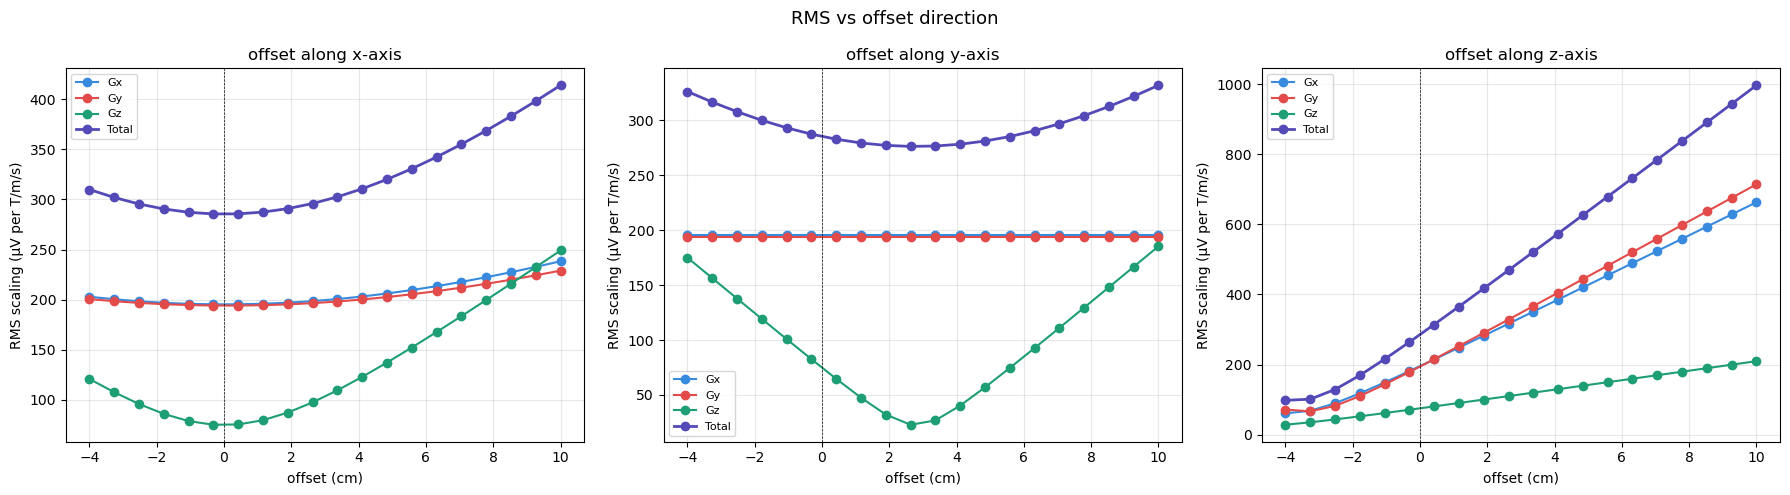

In [48]:
bore_offsets = np.linspace(-0.04, 0.10, 20)
alpha = np.radians(15)

results = {}

for coord in ['x', 'y', 'z']:
    rms_x, rms_y, rms_z, rms_total = [], [], [], []
    
    for offset in bore_offsets:
        sphere_o = SphereModel(info, bore_offset=offset)
        ga_o = GradientArtefact(sphere_o, sequence)
        
        r = sphere_o.radius
        center = sphere_o.center
        n_ch = len(sphere_o.ch_names)
        sx, sy, sz = np.zeros(n_ch), np.zeros(n_ch), np.zeros(n_ch)
        
        ref_idx   = sphere_o.ch_names.index('Cz')
        ref_ep    = sphere_o.eeg_coords_proj[ref_idx] - center
        ref_phi   = np.arctan2(-ref_ep[1], -ref_ep[0])
        ref_theta = np.arccos(np.clip(ref_ep[2] / r, -1, 1))
        
        # set offset in only one coordinate at a time
        x0 = offset if coord == 'x' else 0.0
        y0 = offset if coord == 'y' else 0.0
        z0 = offset if coord == 'z' else 0.0
        
        for i, ep in enumerate(sphere_o.eeg_coords_proj):
            ep_rel = ep - center
            phi   = np.arctan2(-ep_rel[1], -ep_rel[0])
            theta = np.arccos(np.clip(ep_rel[2] / r, -1, 1))

            sx[i] = (ga_o.get_Vx(r, theta, phi, 1.0, x0, y0, z0,alpha=alpha) -
                     ga_o.get_Vx(r, ref_theta, ref_phi, 1.0, x0, y0, z0,alpha=alpha)) * 1e6
            sy[i] = (ga_o.get_Vy(r, theta, phi, 1.0, x0, y0, z0,alpha=alpha) -
                     ga_o.get_Vy(r, ref_theta, ref_phi, 1.0, x0, y0, z0,alpha=alpha)) * 1e6
            sz[i] = (ga_o.get_Vz(r, theta, phi, 1.0, x0, y0, z0, alpha=alpha) -
                     ga_o.get_Vz(r, ref_theta, ref_phi, 1.0, x0, y0, z0, alpha=alpha)) * 1e6

        rms_x.append(np.sqrt(np.mean(sx**2)))
        rms_y.append(np.sqrt(np.mean(sy**2)))
        rms_z.append(np.sqrt(np.mean(sz**2)))
        rms_total.append(np.sqrt(np.mean(sx**2 + sy**2 + sz**2)))
    
    results[coord] = (rms_x, rms_y, rms_z, rms_total)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, coord in zip(axes, ['x', 'y', 'z']):
    rms_x, rms_y, rms_z, rms_total = results[coord]
    ax.plot(bore_offsets*100, rms_x, 'o-', label='Gx', color='#378ADD')
    ax.plot(bore_offsets*100, rms_y, 'o-', label='Gy', color='#E24B4A')
    ax.plot(bore_offsets*100, rms_z, 'o-', label='Gz', color='#1D9E75')
    ax.plot(bore_offsets*100, rms_total, 'o-', label='Total', color='#534AB7', lw=2)
    ax.axvline(0, color='k', lw=0.5, linestyle='--')
    ax.set_xlabel('offset (cm)')
    ax.set_ylabel('RMS scaling (µV per T/m/s)')
    ax.set_title(f'offset along {coord}-axis')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('RMS vs offset direction', fontsize=13)
plt.tight_layout()
plt.show()

In [52]:
# compute sz at two offsets and compare
alpha = np.radians(15)

for z0 in [0.0, -0.03, 0.03]:
    sphere_o = SphereModel(info, bore_offset=0.0)  # keep geometry fixed
    ga_o = GradientArtefact(sphere_o, sequence)
    
    r = sphere_o.radius
    center = sphere_o.center
    n_ch = len(sphere_o.ch_names)
    sz = np.zeros(n_ch)
    
    ref_idx   = sphere_o.ch_names.index('Cz')
    ref_ep    = sphere_o.eeg_coords_proj[ref_idx] - center
    ref_phi   = np.arctan2(-ref_ep[1], -ref_ep[0])
    ref_theta = np.arccos(np.clip(ref_ep[2] / r, -1, 1))
    
    for i, ep in enumerate(sphere_o.eeg_coords_proj):
        ep_rel = ep - center
        phi   = np.arctan2(-ep_rel[1], -ep_rel[0])
        theta = np.arccos(np.clip(ep_rel[2] / r, -1, 1))
        sz[i] = (ga_o.get_Vz(r, theta, phi, 1.0, 0, 0, z0, alpha=alpha) -
                 ga_o.get_Vz(r, ref_theta, ref_phi, 1.0, 0, 0, z0, alpha=alpha)) * 1e6

    print(f"\nz0={z0*100:.0f}cm:")
    print(f"  first 5 values: {sz[:5]}")
    print(f"  mean:           {np.mean(sz):.4f} µV")
    print(f"  mean absolute:  {np.mean(np.abs(sz)):.4f} µV")
    print(f"  RMS:            {np.sqrt(np.mean(sz**2)):.4f} µV")
    print(f"  max absolute:   {np.max(np.abs(sz)):.4f} µV")

Creating sphere model...
Fitted sphere radius:         98.4 mm
Origin head coordinates:      -1.0 13.9 39.1 mm
Origin device coordinates:    -1.0 13.9 39.1 mm

Equiv. model fitting -> RV = 0.00536245 %%
mu1 = 0.945195    lambda1 = 0.136558
mu2 = 0.662341    lambda2 = 0.721742
mu3 = 0.472128    lambda3 = -0.0479307
Set up EEG sphere model with scalp radius    98.4 mm

Storing electrode positions...

z0=0cm:
  first 5 values: [ 23.6457507   -0.15615324 -23.94683488  33.970617    47.26283825]
  mean:           -0.2062 µV
  mean absolute:  65.0188 µV
  RMS:            74.8743 µV
  max absolute:   123.1353 µV
Creating sphere model...
Fitted sphere radius:         98.4 mm
Origin head coordinates:      -1.0 13.9 39.1 mm
Origin device coordinates:    -1.0 13.9 39.1 mm

Equiv. model fitting -> RV = 0.00536245 %%
mu1 = 0.945195    lambda1 = 0.136558
mu2 = 0.662341    lambda2 = 0.721742
mu3 = 0.472128    lambda3 = -0.0479307
Set up EEG sphere model with scalp radius    98.4 mm

Storing electrode 